In [5]:
import matplotlib
import sys

sys.path.append("/kaggle/input/models/minhkhanhdoan/deepland-mid-224/pytorch/default/1")

In [6]:
import torch
import math
import torch.nn as nn
import torch.nn.functional as F

class Flatten(nn.Module):
    def forward(self, x):
        return x.view(x.size(0), -1)

class ChannelGate(nn.Module):
    def __init__(self, gate_channels, reduction_ratio=16):
        super(ChannelGate, self).__init__()
        # if gate_channels // reduction_ratio == 0: #fixed for mobileNetV2
        #     reduction_ratio = gate_channels
        self.mlp = nn.Sequential(
            Flatten(),
            nn.Linear(gate_channels, gate_channels // reduction_ratio),
            nn.ReLU(),
            nn.Linear(gate_channels // reduction_ratio, gate_channels)
            )
    def forward(self, x):
        squeeze_avg = F.avg_pool2d( x, (x.size(2), x.size(3)), stride=(x.size(2), x.size(3)))
        channel_att = self.mlp(squeeze_avg)
        scale = torch.sigmoid(channel_att).unsqueeze(2).unsqueeze(3).expand_as(x)
        return x * scale

class SE(nn.Module):
    def __init__(self, gate_channels, reduction_ratio=16):
        super(SE, self).__init__()
        self.ChannelGate = ChannelGate(gate_channels, reduction_ratio)
    def forward(self, x):
        x_out = self.ChannelGate(x)
        return x_out

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PDPBlock(nn.Module):
    def __init__(self,in_channels,out_channels,s):
        super(PDPBlock,self).__init__()
        self.pw1=nn.Conv2d(in_channels=in_channels,out_channels=in_channels,kernel_size=1,bias=False)
        self.dw1=nn.Conv2d(in_channels=in_channels,out_channels=in_channels,kernel_size=3,stride=s,padding=1,groups=in_channels,dilation=1,bias=False)
        self.dw2=nn.Conv2d(in_channels=in_channels,out_channels=in_channels,kernel_size=3,stride=1,padding=2,groups=in_channels,dilation=2,bias=False)
        self.pw2=nn.Conv2d(in_channels=2*in_channels,out_channels=out_channels,kernel_size=1,bias=False)
        self.SE=SE(out_channels,16); self.s=s
        self.PwR=nn.Conv2d(in_channels=in_channels,out_channels=out_channels,kernel_size=1,stride=s,bias=False)

    def forward(self,x):
      Pw1 = self.pw1(x)

      Dw1 = F.relu(self.dw1(Pw1))
      Dw2 = F.relu(self.dw2(Pw1))

      if self.s == 2:
          Dw2 = F.avg_pool2d(Dw2, kernel_size=2, stride=2)

      Dw = torch.cat([Dw1, Dw2], dim=1)
      Dw = self.shuffle(Dw)

      out = self.pw2(Dw)
      out = self.SE(out)

      if self.s == 1 and x.size() == out.size():
          out = x + out
      else:
          out = self.PwR(x) + out

      return F.relu(out)

    def shuffle(self,x):
        b, c, h, w = x.size()
        g = 2

        x = x.view(b, g, c // g, h, w)
        x = x.permute(0, 2, 1, 3, 4).contiguous()

        return x.view(b, c, h, w)

class NetMid(nn.Module):
    def __init__(self,image_size,n_class=10):
        super(NetMid,self).__init__()
        self.conv1=nn.Conv2d(in_channels=3,out_channels=32,kernel_size=3,stride=2,padding=1,bias=False)
        self.block1=PDPBlock(in_channels=32,out_channels=64, s=1 if image_size == 32 else 2); 
        self.block2=PDPBlock(in_channels=64,out_channels=64,s=1)
        self.block3=PDPBlock(in_channels=64,out_channels=128,s=2); 
        self.block4=PDPBlock(in_channels=128,out_channels=128,s=1)
        self.block5=PDPBlock(in_channels=128,out_channels=256,s=2); 
        self.block6=PDPBlock(in_channels=256,out_channels=256,s=1)
        self.block7=PDPBlock(in_channels=256,out_channels=512,s=2)
        self.conv2=nn.Conv2d(in_channels=512,out_channels=512,kernel_size=1,stride=1,padding=0,bias=False)
        self.avgpool=nn.AdaptiveAvgPool2d(output_size=1); self.dropout=nn.Dropout(p=0.4)
        self.fc=nn.Linear(in_features=512,out_features=n_class)

    def forward(self,x):
        x = F.relu(self.conv1(x))

        x = self.block1(x)
        x = self.block2(x)

        x = self.block3(x)
        x = self.block4(x)

        x = self.block5(x)
        x = self.block6(x)

        x = self.block7(x)

        x = F.relu(self.conv2(x))
        x = self.avgpool(x)

        x = x.view(x.size(0), -1)
        x = self.dropout(x)

        return self.fc(x)

net = NetMid(image_size =224, n_class=100)
net.to("cuda")
from torchsummary import summary
print(net)
summary(net, (3,32,32), device="cuda")

NetMid(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (block1): PDPBlock(
    (pw1): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (dw1): Conv2d(32, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=32, bias=False)
    (dw2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(2, 2), dilation=(2, 2), groups=32, bias=False)
    (pw2): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (SE): SE(
      (ChannelGate): ChannelGate(
        (mlp): Sequential(
          (0): Flatten()
          (1): Linear(in_features=64, out_features=4, bias=True)
          (2): ReLU()
          (3): Linear(in_features=4, out_features=64, bias=True)
        )
      )
    )
    (PwR): Conv2d(32, 64, kernel_size=(1, 1), stride=(2, 2), bias=False)
  )
  (block2): PDPBlock(
    (pw1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (dw1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1

In [8]:
import json
import os
import random
import time
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.amp import autocast, GradScaler

from datasets_224 import get_dataloaders
# from model_defs import NetMid
from train_config import MID_CONFIG
from train_utils import save_history_csv, save_plots


def set_seed(seed=42):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def run_one_epoch(model, loader, criterion, optimizer, device, scaler, is_train):
    model.train() if is_train else model.eval()

    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)
            with autocast("cuda"):
                outputs = model(images)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            with torch.no_grad():
                with autocast("cuda"):
                    outputs = model(images)
                    loss = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    return total_loss / total, 100.0 * correct / total


def train():
    cfg = MID_CONFIG

    data_root = "/kaggle/input/datasets/minhkhanhdoan/dataset-deepland/datasets"  # sửa lại
    output_root = "/kaggle/working"

    set_seed(cfg["seed"])
    os.makedirs(output_root, exist_ok=True)

    device = torch.device("cuda")
    torch.backends.cudnn.benchmark = True

    print("Loading data...")
    train_loader, test_loader, class_names = get_dataloaders(
        data_root=data_root,
        batch_size=16,
        num_workers=4,
        seed=cfg["seed"],
        print_summary=False,
    )

    print("Data ready")

    n_class = len(class_names)
    model = NetMid(image_size=224, n_class=n_class).to(device)
    model = torch.compile(model)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=cfg["learning_rate"], weight_decay=cfg["weight_decay"])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg["epochs"])
    scaler = GradScaler("cuda")

    best_acc = 0.0
    best_epoch = 0
    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
    best = {"epoch": 0, "test_acc": 0.0}

    for epoch in range(1, cfg["epochs"] + 1):
        t0 = time.time()
    
        train_loss, train_acc = run_one_epoch(
            model, train_loader, criterion, optimizer, device, scaler, True
        )
        test_loss, test_acc = run_one_epoch(
            model, test_loader, criterion, optimizer, device, scaler, False
        )
        scheduler.step()
    
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)
    
        print(
            f"Epoch [{epoch}/{cfg['epochs']}] "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.2f}% | "
            f"Test Acc: {test_acc:.2f}%"
        )
    
        save_history_csv(history, f"{output_root}/history.csv")
    
        # ===== BEST =====
        if test_acc > best["test_acc"]:
            best = {"epoch": epoch, "test_acc": test_acc}
            print(f"[BEST] Epoch {epoch} | Acc: {test_acc:.2f}%")
    
            torch.save(model.state_dict(), f"{output_root}/best.pth")
    
    print("BEST:", best)


train()

Loading data...
Data ready
Epoch [1/100] Train Loss: 1.5355 | Train Acc: 27.68% | Test Acc: 22.80%
[BEST] Epoch 1 | Acc: 22.80%
Epoch [2/100] Train Loss: 1.3517 | Train Acc: 39.68% | Test Acc: 43.60%
[BEST] Epoch 2 | Acc: 43.60%
Epoch [3/100] Train Loss: 1.2430 | Train Acc: 44.64% | Test Acc: 42.00%
Epoch [4/100] Train Loss: 1.1286 | Train Acc: 50.04% | Test Acc: 46.80%
[BEST] Epoch 4 | Acc: 46.80%
Epoch [5/100] Train Loss: 1.0643 | Train Acc: 52.12% | Test Acc: 41.20%
Epoch [6/100] Train Loss: 1.0108 | Train Acc: 56.40% | Test Acc: 47.20%
[BEST] Epoch 6 | Acc: 47.20%
Epoch [7/100] Train Loss: 0.9619 | Train Acc: 58.12% | Test Acc: 42.00%
Epoch [8/100] Train Loss: 0.9108 | Train Acc: 60.72% | Test Acc: 43.20%
Epoch [9/100] Train Loss: 0.8825 | Train Acc: 62.64% | Test Acc: 51.20%
[BEST] Epoch 9 | Acc: 51.20%
Epoch [10/100] Train Loss: 0.7910 | Train Acc: 66.24% | Test Acc: 50.40%
Epoch [11/100] Train Loss: 0.7523 | Train Acc: 67.40% | Test Acc: 44.40%
Epoch [12/100] Train Loss: 0.7091 

In [9]:
import matplotlib.pyplot as plt

def plot_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["test_loss"], label="Test Loss")
    plt.legend()
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="Train Acc")
    plt.plot(epochs, history["test_acc"], label="Test Acc")
    plt.legend()
    plt.title("Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.show()

plot_history(history)

NameError: name 'history' is not defined

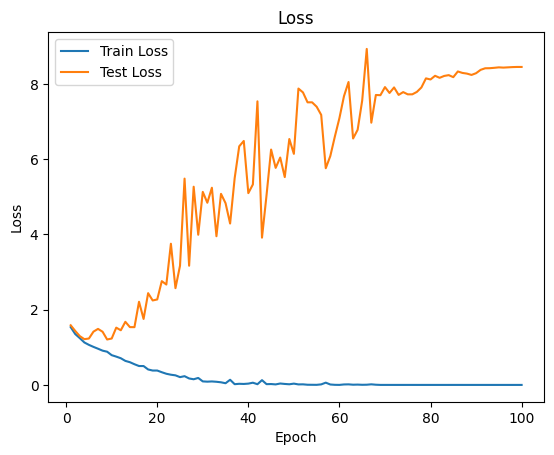

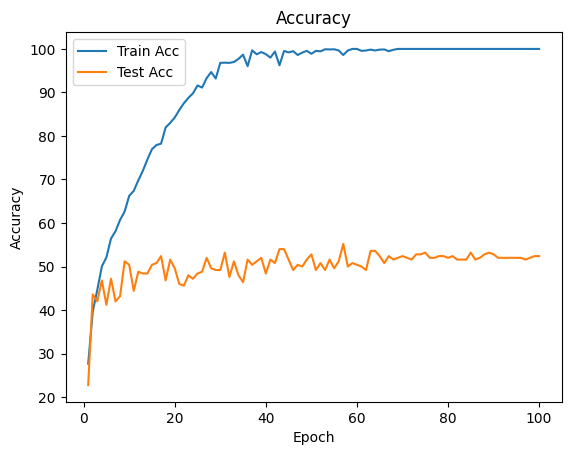

In [10]:
import pandas as pd

df = pd.read_csv("/kaggle/working/history.csv")

history = {
    "train_loss": df["train_loss"].tolist(),
    "test_loss": df["test_loss"].tolist(),
    "train_acc": df["train_acc"].tolist(),
    "test_acc": df["test_acc"].tolist(),
}

plot_history(history)